In [8]:
import json
import sys
import time
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


def resolve_code_root() -> Path:
    cwd = Path.cwd().resolve()
    base = cwd.parent if cwd.name == 'notebooks' else cwd
    if (base / 'utils').exists():
        return base
    if (base / 'phase_3_5_starter' / 'utils').exists():
        return base / 'phase_3_5_starter'
    if (Path('/mnt/data/phase_3_5_starter') / 'utils').exists():
        return Path('/mnt/data/phase_3_5_starter')
    return base

CODE_ROOT = resolve_code_root()
DATA_ROOT = CODE_ROOT
if not ((DATA_ROOT / 'data' / 'score' / 'evaluation_pairs_multiclass.csv').exists() or (DATA_ROOT / 'evaluation_pairs_multiclass.csv').exists()):
    DATA_ROOT = CODE_ROOT.parent

sys.path.append(str(CODE_ROOT))

from utils.eval_helpers import evaluate_multiclass_metrics, save_classification_report

DATA_DIR           = DATA_ROOT if ((DATA_ROOT / 'clean_resume.csv').exists() or (DATA_ROOT / 'clean_job.csv').exists() or (DATA_ROOT / 'job_descriptions.csv').exists() or (DATA_ROOT / 'evaluation_pairs_multiclass.csv').exists()) else (DATA_ROOT / 'data')
SCORE_DIR          = DATA_DIR / 'score'
REPORT_METRICS_DIR = CODE_ROOT / 'reports' / 'metrics'
PLOT_DIR           = CODE_ROOT / 'reports' / 'plots'
MODEL_SAVE_DIR     = CODE_ROOT / 'models' / 'saved'
REPORT_METRICS_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

LABEL_MAP = {0: 'poor_match', 1: 'moderate_match', 2: 'strong_match'}

print('CODE_ROOT =', CODE_ROOT)
print('DATA_ROOT =', DATA_ROOT)


CODE_ROOT = C:\Users\Mr_Root\Downloads\New folder (4)\myproject
DATA_ROOT = C:\Users\Mr_Root\Downloads\New folder (4)\myproject


In [9]:
dataset_path = SCORE_DIR / 'evaluation_pairs_multiclass.csv'
if not dataset_path.exists():
    raise FileNotFoundError(f'Dataset not found: {dataset_path}. Run create_multiclass_dataset.ipynb first.')

df = pd.read_csv(dataset_path)

# Auto-detect feature columns from CSV
# resume_education_rank DROPPED — 99% of values are identical (all 4s), adds noise not signal
META_COLS = [
    'resume_id', 'job_id', 'resume_category', 'job_title',
    'retrieval_bucket', 'silver_score', 'label', 'label_name',
    'matched_required_skills', 'missing_required_skills',
]
DROP_COLS  = ['resume_education_rank']
feature_cols = [c for c in df.columns if c not in META_COLS and c not in DROP_COLS]

# Guard: make sure 10 new engineered features are present in CSV
EXPECTED_NEW = [
    'experience_gap', 'experience_deficit_flag', 'skill_density',
    'semantic_skill_gap', 'hybrid_match_score', 'exp_x_skills',
    'missing_log', 'emb_x_tfidf', 'emb_sq', 'exp_sq',
]
missing_new = [c for c in EXPECTED_NEW if c not in df.columns]
if missing_new:
    raise ValueError(
        f'Engineered features missing from CSV: {missing_new}\n'
        f'Re-run create_multiclass_dataset.ipynb first.'
    )

X      = df[feature_cols].copy()
y      = df['label'].astype(int).copy()
groups = df['resume_id'].copy()

print('Dataset shape:', df.shape)
print(f'Feature cols ({len(feature_cols)}):', feature_cols)
print('Label distribution:')
print(df['label_name'].value_counts())
X.head(3)


Dataset shape: (8931, 42)
Feature cols (31): ['embedding_similarity', 'tfidf_similarity', 'semantic_hint', 'keyword_overlap', 'title_match_score', 'resume_word_count', 'job_word_count', 'length_ratio', 'resume_years_detected', 'job_min_years', 'experience_match_score', 'job_education_rank', 'education_match_score', 'required_skill_coverage', 'preferred_skill_coverage', 'missing_required_skill_ratio', 'missing_required_skill_count', 'skill_match_count', 'project_relevance_score', 'certification_relevance_score', 'job_skill_count', 'experience_gap', 'experience_deficit_flag', 'skill_density', 'semantic_skill_gap', 'hybrid_match_score', 'exp_x_skills', 'missing_log', 'emb_x_tfidf', 'emb_sq', 'exp_sq']
Label distribution:
label_name
moderate_match    2977
poor_match        2977
strong_match      2977
Name: count, dtype: int64


,embedding_similarity,tfidf_similarity,semantic_hint,keyword_overlap,title_match_score,resume_word_count,job_word_count,length_ratio,resume_years_detected,job_min_years,...,experience_gap,experience_deficit_flag,skill_density,semantic_skill_gap,hybrid_match_score,exp_x_skills,missing_log,emb_x_tfidf,emb_sq,exp_sq
0,0.461150,0.145717,0.319205,0.066456,1.0,702.0,89.0,0.126781,0.0,15.0,...,-10.0,1.0,0.0,0.461150,0.298876,0.0,0.693147,0.067197,0.212659,0.000000
1,0.351230,0.068478,0.223992,0.029056,0.0,749.0,51.0,0.068091,0.0,10.0,...,-10.0,1.0,0.0,0.351230,0.223152,0.0,0.693147,0.024052,0.123362,0.000000
2,0.416026,0.083718,0.266487,0.051613,0.0,766.0,68.0,0.088773,10.0,12.0,...,-2.0,1.0,0.0,0.416026,0.255033,0.0,0.693147,0.034829,0.173078,0.694444


In [10]:
# ── Group-aware 3-way split: train / validation / test ────────────────────────
# Why 3 sets:
#   train      → fit the models
#   validation → tune thresholds AND pick the best model
#   test       → final untouched evaluation (never seen during tuning)
# GroupShuffleSplit keeps all pairs from one resume on the same side (no leakage).

# Step 1: 70% train, 30% temp (temp will become val + test)
split_1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(split_1.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)

X_temp      = X.iloc[temp_idx].reset_index(drop=True)
y_temp      = y.iloc[temp_idx].reset_index(drop=True)
groups_temp = groups.iloc[temp_idx].reset_index(drop=True)
df_temp     = df.iloc[temp_idx].reset_index(drop=True)

# Step 2: split temp 50/50 → validation (15%) and test (15%)
split_2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_rel_idx, test_rel_idx = next(split_2.split(X_temp, y_temp, groups=groups_temp))

X_val  = X_temp.iloc[val_rel_idx].reset_index(drop=True)
y_val  = y_temp.iloc[val_rel_idx].reset_index(drop=True)

X_test = X_temp.iloc[test_rel_idx].reset_index(drop=True)
y_test = y_temp.iloc[test_rel_idx].reset_index(drop=True)

meta_test = df_temp.iloc[test_rel_idx][[
    'resume_id', 'job_id', 'resume_category', 'job_title',
    'silver_score', 'label', 'label_name'
]].reset_index(drop=True)

print('Train      :', X_train.shape, '| resumes:', groups.iloc[train_idx].nunique())
print('Validation :', X_val.shape,   '| resumes:', groups_temp.iloc[val_rel_idx].nunique())
print('Test       :', X_test.shape,  '| resumes:', meta_test['resume_id'].nunique())
print()
print('Train label dist :', y_train.value_counts().sort_index().to_dict())
print('Val   label dist :', y_val.value_counts().sort_index().to_dict())
print('Test  label dist :', y_test.value_counts().sort_index().to_dict())


Train      : (6235, 31) | resumes: 1698
Validation : (1331, 31) | resumes: 364
Test       : (1365, 31) | resumes: 364

Train label dist : {0: 2064, 1: 2093, 2: 2078}
Val   label dist : {0: 458, 1: 425, 2: 448}
Test  label dist : {0: 455, 1: 459, 2: 451}


In [11]:
def make_lr_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=4000, class_weight='balanced', random_state=42))
    ])

def make_svm_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42))
    ])

# ── Threshold tuning helpers ──────────────────────────────────────────────────
def apply_thresholds(proba, thresholds):
    """Scale each class probability by its threshold then take argmax."""
    return np.argmax(proba * np.array(thresholds), axis=1)

def tune_thresholds(proba, y_true, n_trials=400):
    """Random search for best [poor, moderate, strong] threshold triplet."""
    best_f1, best_thr = 0.0, [1.0, 1.0, 1.0]
    rng = np.random.default_rng(42)
    for _ in range(n_trials):
        thr = rng.uniform(0.5, 2.5, 3).tolist()
        f = f1_score(y_true, apply_thresholds(proba, thr), average='macro', zero_division=0)
        if f > best_f1:
            best_f1, best_thr = f, thr
    return best_thr, best_f1

def compute_ranking_score(proba):
    """Continuous 0-100 score for HR candidate sorting."""
    return (0.60 * proba[:, 2] + 0.30 * proba[:, 1] + 0.10 * np.max(proba, axis=1)) * 100

def slug(name):
    return name.lower().replace(' ','_').replace('(','').replace(')','').replace('-','_')


# ── Model definitions ─────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
)

gb_model = GradientBoostingClassifier(random_state=42)

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(min_samples_leaf=2, random_state=42),
    n_estimators=250,
    random_state=42,
    n_jobs=1,
)

adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=42),
    n_estimators=220,
    learning_rate=0.8,
    random_state=42,
)

lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=50,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

stacking_model = StackingClassifier(
    estimators=[
        ('lr', make_lr_pipeline()),
        ('rf', RandomForestClassifier(
            n_estimators=220,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1,
        )),
        ('gb', GradientBoostingClassifier(random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=4000, class_weight='balanced', random_state=42),
    cv=3,
    n_jobs=1,
    passthrough=True,
)

models = {
    'Logistic Regression':     make_lr_pipeline(),
    'SVM (RBF)':               make_svm_pipeline(),
    'Random Forest':           rf_model,
    'Gradient Boosting':       gb_model,
    'Bagging (Decision Tree)': bagging_model,
    'AdaBoost':                adaboost_model,
    'LightGBM':                lgbm_model,
    'Stacking Ensemble':       stacking_model,
}

model_family_map = {
    'Logistic Regression':     'Linear',
    'SVM (RBF)':               'Kernel',
    'Random Forest':           'Bagging',
    'Gradient Boosting':       'Boosting',
    'Bagging (Decision Tree)': 'Bagging',
    'AdaBoost':                'Boosting',
    'LightGBM':                'Boosting',
    'Stacking Ensemble':       'Stacking',
}

results         = []
prediction_files = {}
trained_models  = {}
best_thresholds = {}

for model_name, model in models.items():
    print(f'\n=== Training: {model_name} ===')
    fit_start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - fit_start

    pred_start = time.perf_counter()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    pred_seconds = time.perf_counter() - pred_start

    # ── default (untuned) test metrics ────────────────────────────────────────
    metrics = evaluate_multiclass_metrics(y_test, y_pred, y_prob)

    # ── threshold tuning on the VALIDATION set, evaluation on the TEST set ─────
    # Thresholds are learned only from validation data, so the test set stays
    # completely unseen until final evaluation. This is the proper methodology.
    if y_prob is not None:
        y_prob_val = model.predict_proba(X_val)
        best_thr, val_f1_tuned = tune_thresholds(y_prob_val, y_val.values)

        # validation score (untuned) for overfitting check
        y_pred_val = model.predict(X_val)
        val_f1_default = f1_score(y_val.values, y_pred_val, average='macro', zero_division=0)

        # final tuned evaluation on the held-out TEST set
        y_pred_tuned = apply_thresholds(y_prob, best_thr)
        f1_tuned = f1_score(y_test.values, y_pred_tuned, average='macro', zero_division=0)
    else:
        best_thr       = [1.0, 1.0, 1.0]
        f1_tuned       = metrics['f1_macro']
        val_f1_tuned   = metrics['f1_macro']
        val_f1_default = metrics['f1_macro']
    best_thresholds[model_name] = best_thr

    result_row = {
        'model_name':           model_name,
        'model_family':         model_family_map[model_name],
        'fit_seconds':          round(fit_seconds, 3),
        'predict_seconds':      round(pred_seconds, 3),
        'accuracy':             metrics['accuracy'],
        'precision_macro':      metrics['precision_macro'],
        'recall_macro':         metrics['recall_macro'],
        'f1_macro':             metrics['f1_macro'],
        'val_f1_default':       round(val_f1_default, 4),
        'val_f1_tuned':         round(val_f1_tuned, 4),
        'f1_macro_tuned':       round(f1_tuned, 4),
        'improvement':          round(f1_tuned - metrics['f1_macro'], 4),
        'val_test_gap':         round(val_f1_tuned - f1_tuned, 4),
        'precision_weighted':   metrics['precision_weighted'],
        'recall_weighted':      metrics['recall_weighted'],
        'f1_weighted':          metrics['f1_weighted'],
        'roc_auc_ovr_macro':    metrics['roc_auc_ovr_macro'],
        'roc_auc_ovr_weighted': metrics['roc_auc_ovr_weighted'],
    }
    results.append(result_row)
    trained_models[model_name] = model

    # ── save per-model prediction CSV with confidence + ranking_score — new ───
    pred_df = meta_test.copy()
    pred_df['pred_label']      = y_pred
    pred_df['pred_label_name'] = pred_df['pred_label'].map(LABEL_MAP)
    if y_prob is not None:
        pred_df['proba_poor']     = y_prob[:, 0]
        pred_df['proba_moderate'] = y_prob[:, 1]
        pred_df['proba_strong']   = y_prob[:, 2]
        pred_df['confidence']     = np.max(y_prob, axis=1).round(4)
        pred_df['ranking_score']  = compute_ranking_score(y_prob).round(2)
        pred_df['needs_review']   = pred_df['confidence'] < 0.60

    pred_path = REPORT_METRICS_DIR / f'test_predictions_{slug(model_name)}.csv'
    pred_df.to_csv(pred_path, index=False)
    prediction_files[model_name] = pred_path

    report_path = REPORT_METRICS_DIR / f'classification_report_{slug(model_name)}.csv'
    save_classification_report(metrics['classification_report'], report_path)

    print(pd.Series(result_row))
    print(f'Saved predictions -> {pred_path.name}')
    print(f'Saved report      -> {report_path.name}')

# Rank models by VALIDATION tuned F1 (model selection must not use the test set)
results_df = pd.DataFrame(results).sort_values(
    ['val_f1_tuned', 'roc_auc_ovr_macro'], ascending=False
).reset_index(drop=True)
results_df



=== Training: Logistic Regression ===
model_name              Logistic Regression
model_family                         Linear
fit_seconds                           0.221
predict_seconds                       0.005
accuracy                           0.764103
precision_macro                    0.768206
recall_macro                       0.764534
f1_macro                           0.765915
val_f1_default                       0.7881
val_f1_tuned                         0.8194
f1_macro_tuned                       0.7994
improvement                          0.0335
val_test_gap                           0.02
precision_weighted                 0.767744
recall_weighted                    0.764103
f1_weighted                        0.765468
roc_auc_ovr_macro                  0.916712
roc_auc_ovr_weighted                0.91641
dtype: object
Saved predictions -> test_predictions_logistic_regression.csv
Saved report      -> classification_report_logistic_regression.csv

=== Training: SVM (RBF) =

c:\Users\Mr_Root\Downloads\New folder (4)\myproject\myproject\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 4000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


model_name              Stacking Ensemble
model_family                     Stacking
fit_seconds                        43.816
predict_seconds                     0.138
accuracy                         0.824176
precision_macro                  0.828223
recall_macro                     0.824765
f1_macro                         0.824147
val_f1_default                     0.8399
val_f1_tuned                       0.8562
f1_macro_tuned                      0.814
improvement                       -0.0102
val_test_gap                       0.0423
precision_weighted               0.828063
recall_weighted                  0.824176
f1_weighted                      0.823784
roc_auc_ovr_macro                0.939995
roc_auc_ovr_weighted             0.939813
dtype: object
Saved predictions -> test_predictions_stacking_ensemble.csv
Saved report      -> classification_report_stacking_ensemble.csv


,model_name,model_family,fit_seconds,predict_seconds,accuracy,precision_macro,recall_macro,f1_macro,val_f1_default,val_f1_tuned,f1_macro_tuned,improvement,val_test_gap,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr_macro,roc_auc_ovr_weighted
0,Stacking Ensemble,Stacking,43.816,0.138,0.824176,0.828223,0.824765,0.824147,0.8399,0.8562,0.8140,-0.0102,0.0423,0.828063,0.824176,0.823784,0.939995,0.939813
1,Bagging (Decision Tree),Bagging,18.558,0.239,0.834432,0.838627,0.834997,0.834461,0.8523,0.8547,0.8308,-0.0036,0.0238,0.838484,0.834432,0.834118,0.940070,0.939904
2,Gradient Boosting,Boosting,9.154,0.017,0.832234,0.836842,0.832883,0.831601,0.8401,0.8546,0.8188,-0.0128,0.0358,0.836749,0.832234,0.831245,0.940291,0.940117
3,LightGBM,Boosting,3.608,0.205,0.819048,0.822884,0.819476,0.819991,0.8395,0.8451,0.8208,0.0008,0.0243,0.822671,0.819048,0.819675,0.935271,0.935088
4,Random Forest,Bagging,2.573,0.180,0.822711,0.828994,0.823404,0.822159,0.8386,0.8412,0.8169,-0.0052,0.0243,0.828865,0.822711,0.821766,0.936689,0.936513
5,SVM (RBF),Kernel,8.767,1.143,0.811722,0.827489,0.812403,0.811916,0.8235,0.8256,0.8082,-0.0037,0.0174,0.827287,0.811722,0.811500,0.915362,0.915110
6,Logistic Regression,Linear,0.221,0.005,0.764103,0.768206,0.764534,0.765915,0.7881,0.8194,0.7994,0.0335,0.0200,0.767744,0.764103,0.765468,0.916712,0.916410
7,AdaBoost,Boosting,5.964,0.172,0.784615,0.779379,0.785620,0.777639,0.7672,0.8048,0.7922,0.0145,0.0126,0.779159,0.784615,0.777009,0.873500,0.872883


In [12]:

results_path = REPORT_METRICS_DIR / 'model_results.csv'
results_df.to_csv(results_path, index=False)
print('Saved:', results_path)
results_df


Saved: C:\Users\Mr_Root\Downloads\New folder (4)\myproject\reports\metrics\model_results.csv


,model_name,model_family,fit_seconds,predict_seconds,accuracy,precision_macro,recall_macro,f1_macro,val_f1_default,val_f1_tuned,f1_macro_tuned,improvement,val_test_gap,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr_macro,roc_auc_ovr_weighted
0,Stacking Ensemble,Stacking,43.816,0.138,0.824176,0.828223,0.824765,0.824147,0.8399,0.8562,0.8140,-0.0102,0.0423,0.828063,0.824176,0.823784,0.939995,0.939813
1,Bagging (Decision Tree),Bagging,18.558,0.239,0.834432,0.838627,0.834997,0.834461,0.8523,0.8547,0.8308,-0.0036,0.0238,0.838484,0.834432,0.834118,0.940070,0.939904
2,Gradient Boosting,Boosting,9.154,0.017,0.832234,0.836842,0.832883,0.831601,0.8401,0.8546,0.8188,-0.0128,0.0358,0.836749,0.832234,0.831245,0.940291,0.940117
3,LightGBM,Boosting,3.608,0.205,0.819048,0.822884,0.819476,0.819991,0.8395,0.8451,0.8208,0.0008,0.0243,0.822671,0.819048,0.819675,0.935271,0.935088
4,Random Forest,Bagging,2.573,0.180,0.822711,0.828994,0.823404,0.822159,0.8386,0.8412,0.8169,-0.0052,0.0243,0.828865,0.822711,0.821766,0.936689,0.936513
5,SVM (RBF),Kernel,8.767,1.143,0.811722,0.827489,0.812403,0.811916,0.8235,0.8256,0.8082,-0.0037,0.0174,0.827287,0.811722,0.811500,0.915362,0.915110
6,Logistic Regression,Linear,0.221,0.005,0.764103,0.768206,0.764534,0.765915,0.7881,0.8194,0.7994,0.0335,0.0200,0.767744,0.764103,0.765468,0.916712,0.916410
7,AdaBoost,Boosting,5.964,0.172,0.784615,0.779379,0.785620,0.777639,0.7672,0.8048,0.7922,0.0145,0.0126,0.779159,0.784615,0.777009,0.873500,0.872883


Best model (chosen on validation): Stacking Ensemble
  Validation tuned F1 : 0.8562
  Test tuned F1       : 0.8140
  Val-Test gap        : +0.0423  (small gap = no overfitting)

model_name              Stacking Ensemble
model_family                     Stacking
fit_seconds                        43.816
predict_seconds                     0.138
accuracy                         0.824176
precision_macro                  0.828223
recall_macro                     0.824765
f1_macro                         0.824147
val_f1_default                     0.8399
val_f1_tuned                       0.8562
f1_macro_tuned                      0.814
improvement                       -0.0102
val_test_gap                       0.0423
precision_weighted               0.828063
recall_weighted                  0.824176
f1_weighted                      0.823784
roc_auc_ovr_macro                0.939995
roc_auc_ovr_weighted             0.939813
Name: 0, dtype: object

=== Best Model — Classification Report (fu

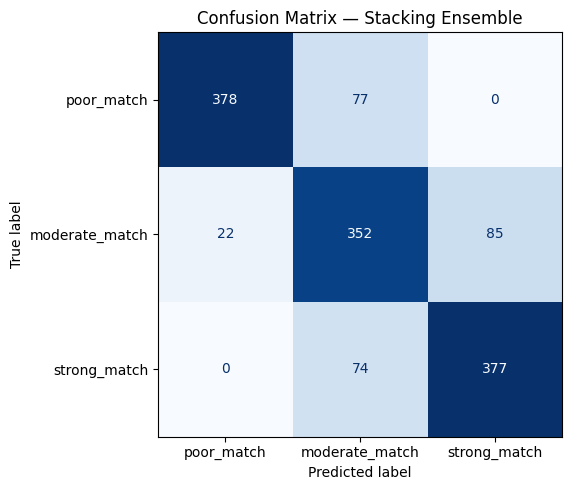

Top 15 features:
semantic_hint             11667
embedding_similarity      10143
hybrid_match_score         8964
keyword_overlap            8540
emb_x_tfidf                7414
semantic_skill_gap         6522
tfidf_similarity           5966
length_ratio               5529
job_min_years              4847
resume_word_count          4839
job_word_count             4647
experience_gap             1898
emb_sq                     1487
resume_years_detected      1317
experience_match_score     1040
dtype: int32


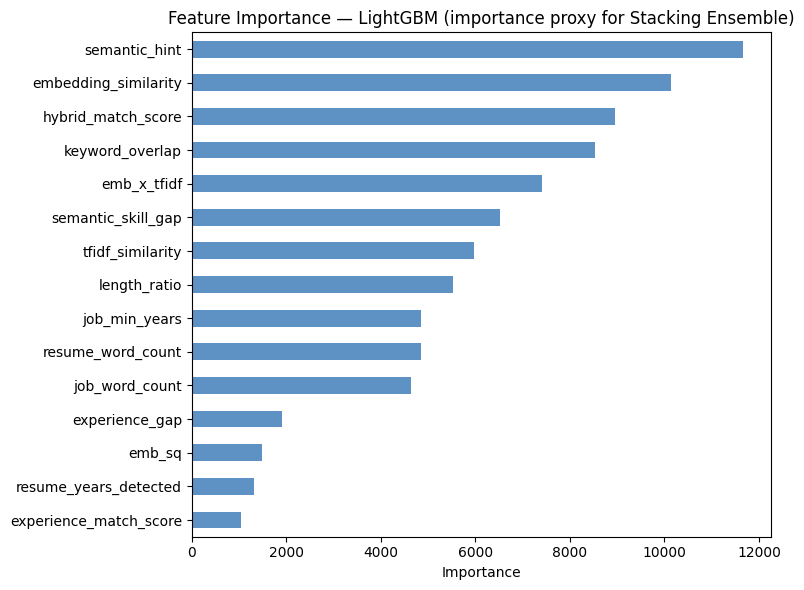


Refitting Stacking Ensemble on full dataset (8931 rows)...
Saved deployment bundle: C:\Users\Mr_Root\Downloads\New folder (4)\myproject\models\saved\best_model_bundle.joblib
Thresholds [poor, moderate, strong]: [1.46, 1.867, 0.957]
Saved: C:\Users\Mr_Root\Downloads\New folder (4)\myproject\reports\metrics\best_model_test_predictions.csv
Candidates needing HR review: 84 / 1365
Saved: C:\Users\Mr_Root\Downloads\New folder (4)\myproject\models\saved\feature_columns.json

✓ Done.


c:\Users\Mr_Root\Downloads\New folder (4)\myproject\myproject\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 4000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
# Pick best model by VALIDATION tuned F1 (selection never uses the test set)
best_row        = results_df.sort_values(['val_f1_tuned', 'roc_auc_ovr_macro'], ascending=False).iloc[0]
best_model_name = best_row['model_name']
best_model      = trained_models[best_model_name]
best_thr        = best_thresholds[best_model_name]

print('Best model (chosen on validation):', best_model_name)
print(f"  Validation tuned F1 : {best_row['val_f1_tuned']:.4f}")
print(f"  Test tuned F1       : {best_row['f1_macro_tuned']:.4f}")
print(f"  Val-Test gap        : {best_row['val_test_gap']:+.4f}  (small gap = no overfitting)")
print()
print(best_row)

# ── Full report + confusion matrix ────────────────────────────────────────────
y_prob_best = best_model.predict_proba(X_test)
y_pred_best = apply_thresholds(y_prob_best, best_thr)

print('\n=== Best Model — Classification Report (full test set, threshold-tuned) ===')
print(classification_report(
    y_test, y_pred_best,
    target_names=['poor_match', 'moderate_match', 'strong_match'],
    digits=4,
))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['poor_match', 'moderate_match', 'strong_match'],
    cmap='Blues', ax=ax, colorbar=False,
)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_matrix_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Feature importance ────────────────────────────────────────────────────────
# Some models (Stacking) have no feature_importances_. In that case we fall back
# to a tree model (LightGBM, else Random Forest) so this plot ALWAYS generates.
_fi_source = None
_fi_source_name = best_model_name
if hasattr(best_model, 'feature_importances_'):
    _fi_source = best_model
elif 'LightGBM' in trained_models and hasattr(trained_models['LightGBM'], 'feature_importances_'):
    _fi_source = trained_models['LightGBM']
    _fi_source_name = 'LightGBM (importance proxy for ' + best_model_name + ')'
elif 'Random Forest' in trained_models and hasattr(trained_models['Random Forest'], 'feature_importances_'):
    _fi_source = trained_models['Random Forest']
    _fi_source_name = 'Random Forest (importance proxy for ' + best_model_name + ')'

if _fi_source is not None:
    fi = pd.Series(_fi_source.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print('Top 15 features:')
    print(fi.head(15).round(4))
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    fi.head(15)[::-1].plot(kind='barh', ax=ax2, color='#5e92c4')
    ax2.set_title(f'Feature Importance — {_fi_source_name}')
    ax2.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'feature_importance_best_model.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No feature importance available from any trained model.')

# ── Refit on full dataset ─────────────────────────────────────────────────────
print(f'\nRefitting {best_model_name} on full dataset ({len(X)} rows)...')
best_model.fit(X, y)

# ── Save bundle with thresholds ───────────────────────────────────────────────
bundle = {
    'model_name':      best_model_name,
    'model_family':    best_row.get('model_family', ''),
    'model':           best_model,
    'feature_columns': feature_cols,
    'label_map':       LABEL_MAP,
    'thresholds':      best_thr,
    'test_macro_f1':   best_row['f1_macro_tuned'],
    'metrics_table':   results_df.to_dict(orient='records'),
}

bundle_path = MODEL_SAVE_DIR / 'best_model_bundle.joblib'
joblib.dump(bundle, bundle_path)
print('Saved deployment bundle:', bundle_path)
print(f'Thresholds [poor, moderate, strong]: {[round(t, 3) for t in best_thr]}')

# ── Save best predictions with confidence + ranking_score ─────────────────────
best_pred_df = meta_test.copy()
best_pred_df['pred_label']      = y_pred_best
best_pred_df['pred_label_name'] = pd.Series(y_pred_best).map(LABEL_MAP)
best_pred_df['proba_poor']      = y_prob_best[:, 0].round(4)
best_pred_df['proba_moderate']  = y_prob_best[:, 1].round(4)
best_pred_df['proba_strong']    = y_prob_best[:, 2].round(4)
best_pred_df['confidence']      = np.max(y_prob_best, axis=1).round(4)
best_pred_df['ranking_score']   = compute_ranking_score(y_prob_best).round(2)
best_pred_df['needs_review']    = best_pred_df['confidence'] < 0.60

best_pred_dst = REPORT_METRICS_DIR / 'best_model_test_predictions.csv'
best_pred_df.to_csv(best_pred_dst, index=False)
print('Saved:', best_pred_dst)
print(f'Candidates needing HR review: {best_pred_df["needs_review"].sum()} / {len(best_pred_df)}')

with open(MODEL_SAVE_DIR / 'feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, indent=2)
print('Saved:', MODEL_SAVE_DIR / 'feature_columns.json')
print('\n✓ Done.')


Logistic Regression       mean=0.7825  std=0.0122  folds=[np.float64(0.797), np.float64(0.776), np.float64(0.763), np.float64(0.783), np.float64(0.793)]
Random Forest             mean=0.8331  std=0.0072  folds=[np.float64(0.837), np.float64(0.829), np.float64(0.824), np.float64(0.845), np.float64(0.83)]
Gradient Boosting         mean=0.8407  std=0.0083  folds=[np.float64(0.849), np.float64(0.84), np.float64(0.829), np.float64(0.851), np.float64(0.835)]
LightGBM                  mean=0.8280  std=0.0127  folds=[np.float64(0.842), np.float64(0.819), np.float64(0.813), np.float64(0.844), np.float64(0.821)]

Saved: C:\Users\Mr_Root\Downloads\New folder (4)\myproject\reports\metrics\cross_validation_results.csv


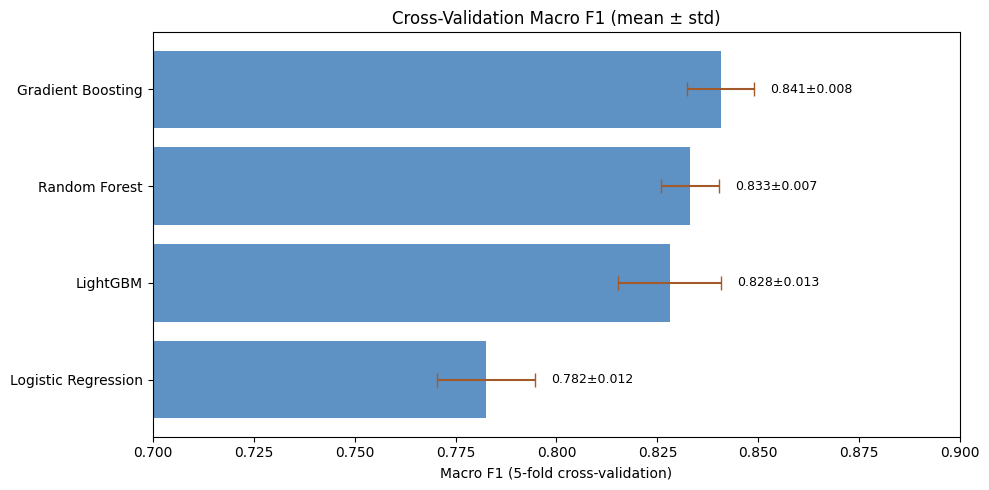


Saved plot: cross_validation_f1.png


,model_name,cv_mean_f1,cv_std_f1,fold_scores
0,Gradient Boosting,0.8407,0.0083,"[0.8485, 0.8396, 0.829, 0.8513, 0.835]"
1,Random Forest,0.8331,0.0072,"[0.8373, 0.8293, 0.8241, 0.8449, 0.8298]"
2,LightGBM,0.8280,0.0127,"[0.8424, 0.8193, 0.8135, 0.8441, 0.8207]"
3,Logistic Regression,0.7825,0.0122,"[0.7973, 0.7757, 0.7634, 0.7827, 0.7931]"


In [14]:
# ── Cross-validation: confirm models are stable, not lucky on one split ──────
#
# A single train/test split can be lucky or unlucky. Cross-validation trains
# and tests on 5 different folds, so we see the average performance AND how
# much it varies (std). A low std means the model is stable and trustworthy.
#
# StratifiedGroupKFold keeps class balance AND keeps each resume in one fold
# (no leakage) — the same group-aware principle as the main split.

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# CV is run on a representative subset for speed.
# Stacking is excluded here because it is very slow under 5-fold CV,
# but you can add 'Stacking Ensemble' to this list if you want.
CV_MODELS = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'LightGBM']

cv_rows = []
for name in CV_MODELS:
    model = models[name]
    scores = cross_val_score(
        model, X, y,
        groups=groups,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
    )
    cv_rows.append({
        'model_name': name,
        'cv_mean_f1': round(scores.mean(), 4),
        'cv_std_f1':  round(scores.std(), 4),
        'fold_scores': [round(s, 4) for s in scores],
    })
    print(f'{name:24s}  mean={scores.mean():.4f}  std={scores.std():.4f}  folds={[round(s,3) for s in scores]}')

cv_df = pd.DataFrame(cv_rows).sort_values('cv_mean_f1', ascending=False).reset_index(drop=True)
cv_df.to_csv(REPORT_METRICS_DIR / 'cross_validation_results.csv', index=False)
print('\nSaved:', REPORT_METRICS_DIR / 'cross_validation_results.csv')

# ── Plot: CV mean F1 with std error bars ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
cv_sorted = cv_df.sort_values('cv_mean_f1', ascending=True)
ax.barh(
    cv_sorted['model_name'], cv_sorted['cv_mean_f1'],
    xerr=cv_sorted['cv_std_f1'], color='#5e92c4',
    capsize=5, error_kw={'ecolor': '#a35a2a', 'lw': 1.5},
)
ax.set_xlabel('Macro F1 (5-fold cross-validation)')
ax.set_title('Cross-Validation Macro F1 (mean \u00b1 std)')
ax.set_xlim(0.70, 0.90)
for i, (m, s) in enumerate(zip(cv_sorted['cv_mean_f1'], cv_sorted['cv_std_f1'])):
    ax.text(m + s + 0.004, i, f'{m:.3f}\u00b1{s:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'cross_validation_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSaved plot: cross_validation_f1.png')
cv_df


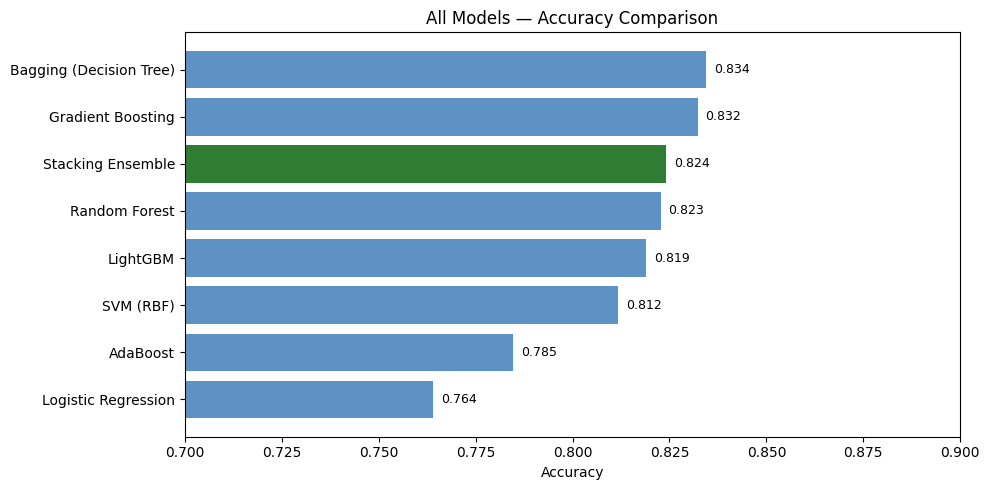

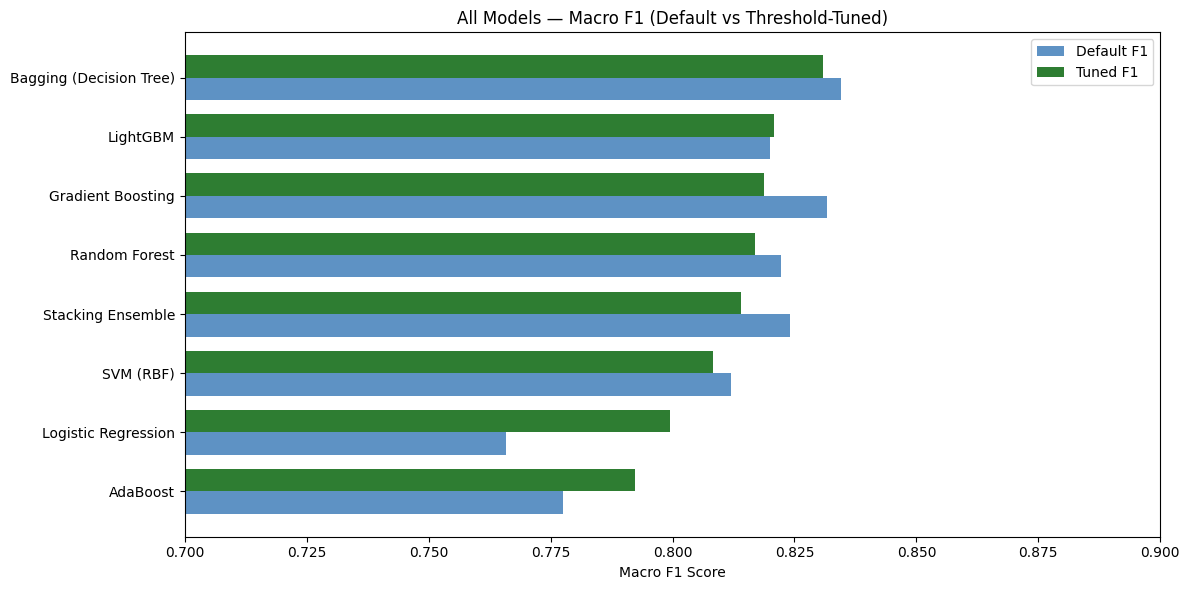

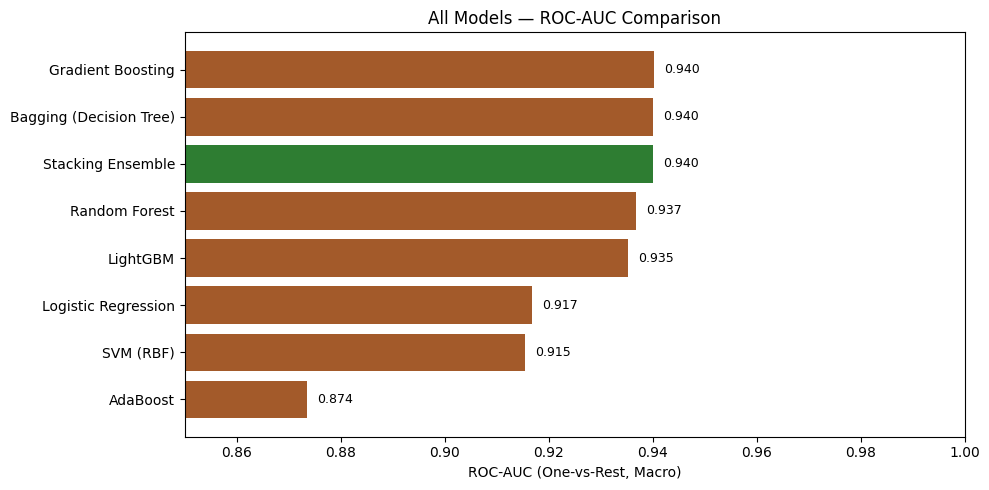

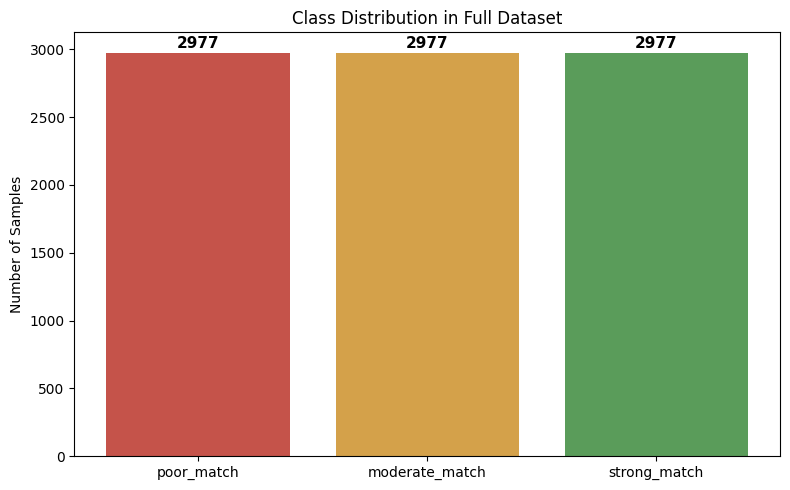

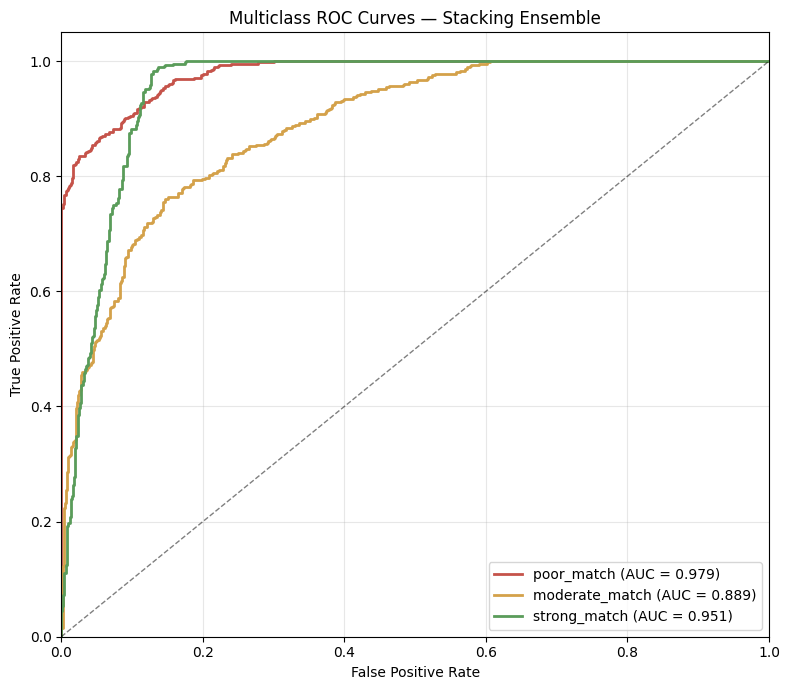

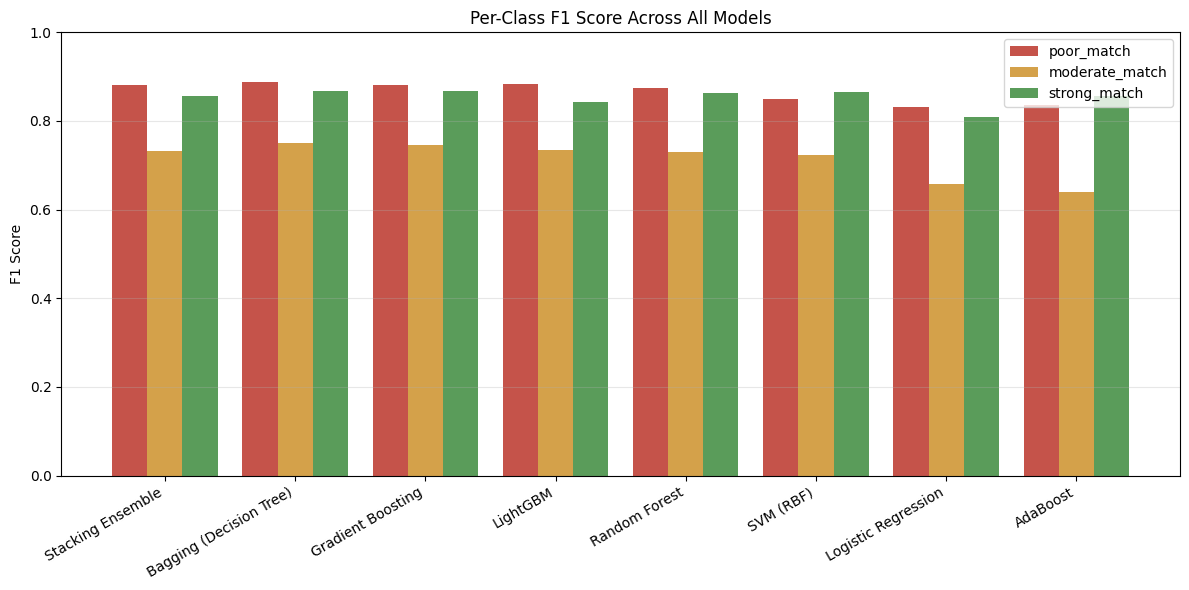

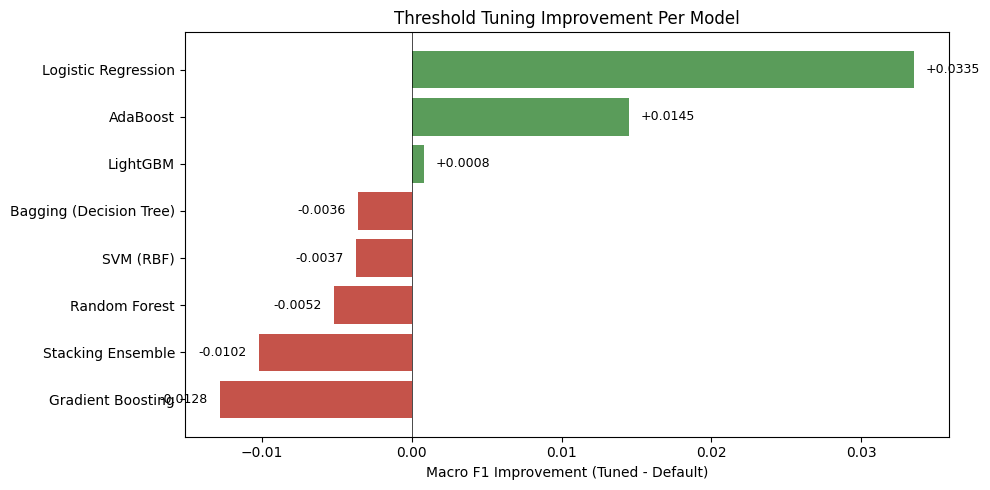


✓ All comparison plots saved to: C:\Users\Mr_Root\Downloads\New folder (4)\myproject\reports\plots
   1. all_models_comparison_accuracy.png
   2. model_comparison_macro_f1.png
   3. model_comparison_roc_auc.png
   4. class_distribution.png
   5. multiclass_roc_best_model.png
   6. per_class_f1_comparison.png
   7. threshold_tuning_improvement.png


In [15]:
# ── Additional plots: all-model comparisons, ROC curves, class distribution ──
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ── 1. All models accuracy comparison ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sorted_df = results_df.sort_values('accuracy', ascending=True)
colors = ['#2e7d32' if name == best_model_name else '#5e92c4' for name in sorted_df['model_name']]
ax.barh(sorted_df['model_name'], sorted_df['accuracy'], color=colors)
ax.set_xlabel('Accuracy')
ax.set_title('All Models — Accuracy Comparison')
ax.set_xlim(0.70, 0.90)
for i, v in enumerate(sorted_df['accuracy']):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'all_models_comparison_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. All models Macro F1 comparison (default vs tuned) ──────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
sorted_df = results_df.sort_values('f1_macro_tuned', ascending=True)
x = np.arange(len(sorted_df))
width = 0.38
ax.barh(x - width/2, sorted_df['f1_macro'],       width, label='Default F1', color='#5e92c4')
ax.barh(x + width/2, sorted_df['f1_macro_tuned'], width, label='Tuned F1',   color='#2e7d32')
ax.set_yticks(x)
ax.set_yticklabels(sorted_df['model_name'])
ax.set_xlabel('Macro F1 Score')
ax.set_title('All Models — Macro F1 (Default vs Threshold-Tuned)')
ax.legend()
ax.set_xlim(0.70, 0.90)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_comparison_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. All models ROC-AUC comparison ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sorted_df = results_df.sort_values('roc_auc_ovr_macro', ascending=True)
colors = ['#2e7d32' if name == best_model_name else '#a35a2a' for name in sorted_df['model_name']]
ax.barh(sorted_df['model_name'], sorted_df['roc_auc_ovr_macro'], color=colors)
ax.set_xlabel('ROC-AUC (One-vs-Rest, Macro)')
ax.set_title('All Models — ROC-AUC Comparison')
ax.set_xlim(0.85, 1.00)
for i, v in enumerate(sorted_df['roc_auc_ovr_macro']):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_comparison_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Class distribution in training data ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
class_counts = df['label_name'].value_counts().reindex(['poor_match', 'moderate_match', 'strong_match'])
colors = ['#c5534a', '#d4a14a', '#5a9c5a']
bars = ax.bar(class_counts.index, class_counts.values, color=colors)
ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution in Full Dataset')
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Multiclass ROC curves for best model (one-vs-rest) ─────────────────────
y_test_binary = label_binarize(y_test, classes=[0, 1, 2])
class_names = ['poor_match', 'moderate_match', 'strong_match']
class_colors = ['#c5534a', '#d4a14a', '#5a9c5a']

fig, ax = plt.subplots(figsize=(8, 7))
for i, (cname, color) in enumerate(zip(class_names, class_colors)):
    fpr, tpr, _ = roc_curve(y_test_binary[:, i], y_prob_best[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cname} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Multiclass ROC Curves — {best_model_name}')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'multiclass_roc_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. Per-class F1 score across all models ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
model_names_list = []
poor_f1, mod_f1, strong_f1 = [], [], []

for name in results_df['model_name']:
    report_path = REPORT_METRICS_DIR / f'classification_report_{slug(name)}.csv'
    if report_path.exists():
        rep = pd.read_csv(report_path, index_col=0)
        model_names_list.append(name)
        poor_f1.append(rep.loc['poor_match', 'f1-score'])
        mod_f1.append(rep.loc['moderate_match', 'f1-score'])
        strong_f1.append(rep.loc['strong_match', 'f1-score'])

x = np.arange(len(model_names_list))
width = 0.27
ax.bar(x - width, poor_f1,   width, label='poor_match',     color='#c5534a')
ax.bar(x,         mod_f1,    width, label='moderate_match', color='#d4a14a')
ax.bar(x + width, strong_f1, width, label='strong_match',   color='#5a9c5a')
ax.set_xticks(x)
ax.set_xticklabels(model_names_list, rotation=30, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score Across All Models')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'per_class_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7. Improvement from threshold tuning ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sorted_df = results_df.sort_values('improvement', ascending=True)
colors = ['#5a9c5a' if v >= 0 else '#c5534a' for v in sorted_df['improvement']]
ax.barh(sorted_df['model_name'], sorted_df['improvement'], color=colors)
ax.set_xlabel('Macro F1 Improvement (Tuned - Default)')
ax.set_title('Threshold Tuning Improvement Per Model')
ax.axvline(0, color='black', lw=0.5)
for i, v in enumerate(sorted_df['improvement']):
    offset = 0.0008 if v >= 0 else -0.0008
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f'{v:+.4f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'threshold_tuning_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ All comparison plots saved to:', PLOT_DIR)
print('   1. all_models_comparison_accuracy.png')
print('   2. model_comparison_macro_f1.png')
print('   3. model_comparison_roc_auc.png')
print('   4. class_distribution.png')
print('   5. multiclass_roc_best_model.png')
print('   6. per_class_f1_comparison.png')
print('   7. threshold_tuning_improvement.png')
